In [1]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import geopandas as gpd
import xarray as xr

In [2]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/Met/RH_Combined_data.csv'

# Read the CSV file into a pandas DataFrame
RHH = pd.read_csv(csv_file_path, sep = ',', skiprows=0)

RHH = RHH.rename(columns={'1st Max Value': 'Sample Measurement', 'Arithmetic Mean': 'MDL'})


RHH['Timestamp'] = pd.to_datetime(RHH['Date Local'])
RHH = RHH[RHH['Units of Measure'] == 'Percent relative humidity']
RHH = RHH[RHH['Timestamp'].dt.year >= 2010]

RHH

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change,Timestamp
38181,4,3,8001,62201,1,32.009410,-109.389060,WGS84,Relative Humidity,1 HOUR,...,12,INSTRUMENTAL - HYGROSCOPIC PLASTIC FILM,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-01
38182,4,3,8001,62201,1,32.009410,-109.389060,WGS84,Relative Humidity,1 HOUR,...,12,INSTRUMENTAL - HYGROSCOPIC PLASTIC FILM,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-02
38183,4,3,8001,62201,1,32.009410,-109.389060,WGS84,Relative Humidity,1 HOUR,...,12,INSTRUMENTAL - HYGROSCOPIC PLASTIC FILM,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-03
38184,4,3,8001,62201,1,32.009410,-109.389060,WGS84,Relative Humidity,1 HOUR,...,12,INSTRUMENTAL - HYGROSCOPIC PLASTIC FILM,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-04
38185,4,3,8001,62201,1,32.009410,-109.389060,WGS84,Relative Humidity,1 HOUR,...,12,INSTRUMENTAL - HYGROSCOPIC PLASTIC FILM,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87210,4,19,1113,62201,1,32.251843,-110.965293,WGS84,Relative Humidity,1 HOUR,...,11,INSTRUMENTAL - HYGROTHERMOGRAPH ELEC OR MACH AVG,GERONIMO,2498 N. GERONIMO,Arizona,Pima,Tucson,"Tucson, AZ",2023-02-16,2022-12-27
87211,4,19,1113,62201,1,32.251843,-110.965293,WGS84,Relative Humidity,1 HOUR,...,11,INSTRUMENTAL - HYGROTHERMOGRAPH ELEC OR MACH AVG,GERONIMO,2498 N. GERONIMO,Arizona,Pima,Tucson,"Tucson, AZ",2023-02-16,2022-12-28
87212,4,19,1113,62201,1,32.251843,-110.965293,WGS84,Relative Humidity,1 HOUR,...,11,INSTRUMENTAL - HYGROTHERMOGRAPH ELEC OR MACH AVG,GERONIMO,2498 N. GERONIMO,Arizona,Pima,Tucson,"Tucson, AZ",2023-02-16,2022-12-29
87213,4,19,1113,62201,1,32.251843,-110.965293,WGS84,Relative Humidity,1 HOUR,...,11,INSTRUMENTAL - HYGROTHERMOGRAPH ELEC OR MACH AVG,GERONIMO,2498 N. GERONIMO,Arizona,Pima,Tucson,"Tucson, AZ",2023-02-16,2022-12-30


In [3]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/Met/Temp_Combined_data.csv'

# Read the CSV file into a pandas DataFrame
Temp = pd.read_csv(csv_file_path, sep = ',', skiprows=0)

Temp = Temp.rename(columns={'1st Max Value': 'Sample Measurement', 'Arithmetic Mean': 'MDL'})


Temp['Timestamp'] = pd.to_datetime(Temp['Date Local'])
#Temp = Temp[Temp['Units of Measure'] == 'Percent relative humidity']
Temp = Temp[Temp['Timestamp'].dt.year >= 2010]
Temp['Sample Measurement'] = (Temp['Sample Measurement'] - 32) * 5 / 9
Temp

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change,Timestamp
47411,4,3,8001,62101,1,32.009410,-109.389060,WGS84,Outdoor Temperature,1 HOUR,...,41,INSTRUMENTAL - ELEC. OR MACH. AVG. LEVEL 1,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-01
47412,4,3,8001,62101,1,32.009410,-109.389060,WGS84,Outdoor Temperature,1 HOUR,...,41,INSTRUMENTAL - ELEC. OR MACH. AVG. LEVEL 1,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-02
47413,4,3,8001,62101,1,32.009410,-109.389060,WGS84,Outdoor Temperature,1 HOUR,...,41,INSTRUMENTAL - ELEC. OR MACH. AVG. LEVEL 1,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-03
47414,4,3,8001,62101,1,32.009410,-109.389060,WGS84,Outdoor Temperature,1 HOUR,...,41,INSTRUMENTAL - ELEC. OR MACH. AVG. LEVEL 1,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-04
47415,4,3,8001,62101,1,32.009410,-109.389060,WGS84,Outdoor Temperature,1 HOUR,...,41,INSTRUMENTAL - ELEC. OR MACH. AVG. LEVEL 1,Chiricahua NM - Entrance Station,CHIRICAHUA NATIONAL MOUMENT,Arizona,Cochise,Not in a city,"Sierra Vista-Douglas, AZ",2013-06-10,2010-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116089,4,19,1113,62101,1,32.251843,-110.965293,WGS84,Outdoor Temperature,1 HOUR,...,40,INSTRUMENTAL - ELECTRONIC OR MACHINE AVG.,GERONIMO,2498 N. GERONIMO,Arizona,Pima,Tucson,"Tucson, AZ",2023-02-16,2022-12-27
116090,4,19,1113,62101,1,32.251843,-110.965293,WGS84,Outdoor Temperature,1 HOUR,...,40,INSTRUMENTAL - ELECTRONIC OR MACHINE AVG.,GERONIMO,2498 N. GERONIMO,Arizona,Pima,Tucson,"Tucson, AZ",2023-02-16,2022-12-28
116091,4,19,1113,62101,1,32.251843,-110.965293,WGS84,Outdoor Temperature,1 HOUR,...,40,INSTRUMENTAL - ELECTRONIC OR MACHINE AVG.,GERONIMO,2498 N. GERONIMO,Arizona,Pima,Tucson,"Tucson, AZ",2023-02-16,2022-12-29
116092,4,19,1113,62101,1,32.251843,-110.965293,WGS84,Outdoor Temperature,1 HOUR,...,40,INSTRUMENTAL - ELECTRONIC OR MACHINE AVG.,GERONIMO,2498 N. GERONIMO,Arizona,Pima,Tucson,"Tucson, AZ",2023-02-16,2022-12-30


In [4]:
list(Temp)

['State Code',
 'County Code',
 'Site Num',
 'Parameter Code',
 'POC',
 'Latitude',
 'Longitude',
 'Datum',
 'Parameter Name',
 'Sample Duration',
 'Pollutant Standard',
 'Date Local',
 'Units of Measure',
 'Event Type',
 'Observation Count',
 'Observation Percent',
 'MDL',
 'Sample Measurement',
 '1st Max Hour',
 'AQI',
 'Method Code',
 'Method Name',
 'Local Site Name',
 'Address',
 'State Name',
 'County Name',
 'City Name',
 'CBSA Name',
 'Date of Last Change',
 'Timestamp']

In [5]:
def extract_location_monthly_avgg(df, long_min, long_max, lat_min, lat_max):
    # Filter rows based on the longitude and latitude range
    location_df = df[(df['Longitude'] >= long_min) & (df['Longitude'] <= long_max) &
                     (df['Latitude'] >= lat_min) & (df['Latitude'] <= lat_max)].copy()
    
    # Select necessary columns
    location_df = location_df[['Latitude', 'Longitude', 'Timestamp', 'Sample Measurement', 'MDL']].copy()
    
    # Convert 'Timestamp' column to datetime if it's not already
    location_df['Timestamp'] = pd.to_datetime(location_df['Timestamp'])
    
    # Set 'Timestamp' column as the index
    location_df.set_index('Timestamp', inplace=True)
    
    # Calculate the monthly average for 'Sample Measurement' and 'MDL'
    monthly_avg_df = location_df.resample('M').mean()
    
    # Group by month (from 1 to 12) and then calculate the mean across all years
    monthly_avg_df = monthly_avg_df.groupby(monthly_avg_df.index.month).mean()
    
    # Assign month names directly to the index
    monthly_avg_df.index = ['January', 'February', 'March', 'April', 'May', 'June', 
                            'July', 'August', 'September', 'October', 'November', 'December']
    
    return monthly_avg_df

# Define the longitude and latitude ranges for Tucson
long_min, long_max = -111.12716, -110.737116
lat_min, lat_max = 31.87952, 32.425261

# Example usage:
# Assuming 'df' is your DataFrame containing the required data columns
tucson_monthly_avgg = extract_location_monthly_avgg(Temp, long_min, long_max, lat_min, lat_max)
print(tucson_monthly_avgg)


            Latitude   Longitude  Sample Measurement        MDL
January    32.191374 -110.923985           19.130903  52.520298
February   32.191157 -110.923749           20.382652  55.315342
March      32.191163 -110.923748           24.468034  62.686899
April      32.201759 -110.940833           28.380563  69.847415
May        32.201202 -110.940217           32.202073  76.922526
June       32.201095 -110.940077           38.335897  88.062913
July       32.200926 -110.940734           36.892883  87.063511
August     32.201023 -110.940742           36.517568  86.148291
September  32.201428 -110.941163           34.475341  82.059531
October    32.192191 -110.926711           29.943761  72.082688
November   32.191547 -110.926064           24.007455  61.084622
December   32.192156 -110.926643           18.656649  52.422969


In [6]:
def extract_location_monthly_avg(df, long_min, long_max, lat_min, lat_max):
    # Filter rows based on the longitude and latitude range
    location_df = df[(df['Longitude'] >= long_min) & (df['Longitude'] <= long_max) &
                     (df['Latitude'] >= lat_min) & (df['Latitude'] <= lat_max)].copy()
    
    # Select necessary columns
    location_df = location_df[['Latitude', 'Longitude', 'Timestamp', 'Sample Measurement', 'MDL']].copy()
    
    # Convert 'Timestamp' column to datetime if it's not already
    location_df['Timestamp'] = pd.to_datetime(location_df['Timestamp'])
    
    # Set 'Timestamp' column as the index
    location_df.set_index('Timestamp', inplace=True)
    
    # Calculate the monthly average for 'Sample Measurement' and 'MDL'
    monthly_avg_df = location_df.resample('M').mean()
    
    # Extract the month and year for better readability
    monthly_avg_df['Year'] = monthly_avg_df.index.year
    monthly_avg_df['Month'] = monthly_avg_df.index.month_name()
    
    # Group by month (from 1 to 12) and then calculate the mean across all years
    
    return monthly_avg_df

# Define the longitude and latitude ranges for Tucson
long_min, long_max = -111.12716, -110.737116
lat_min, lat_max = 31.87952, 32.425261

# Example usage:
# Assuming 'df' is your DataFrame containing the required data columns
tucson_monthly_avg = extract_location_monthly_avg(Temp, long_min, long_max, lat_min, lat_max)
print(tucson_monthly_avg)


             Latitude   Longitude  Sample Measurement        MDL  Year   
Timestamp                                                                
2010-01-31  32.187089 -110.917882           18.454757  52.930115  2010  \
2010-02-28  32.184223 -110.914926           17.920274  53.106157  2010   
2010-03-31  32.184223 -110.914926           21.787227  58.423998  2010   
2010-04-30  32.198639 -110.938857           25.825103  65.639815  2010   
2010-05-31  32.198639 -110.938857           31.358025  74.494773  2010   
...               ...         ...                 ...        ...   ...   
2022-08-31  32.203115 -110.949834           34.248941  82.872407  2022   
2022-09-30  32.203115 -110.949834           34.466330  82.076636  2022   
2022-10-31  32.203115 -110.949834           27.512219  68.993249  2022   
2022-11-30  32.203115 -110.949834           21.265993  55.379310  2022   
2022-12-31  32.203115 -110.949834           17.846204  51.214594  2022   

                Month  
Timestamp    

In [7]:
tucson_monthly_avg

,Latitude,Longitude,Sample Measurement,MDL,Year,Month
Timestamp,,,,,,
2010-01-31,32.187089,-110.917882,18.454757,52.930115,2010,January
2010-02-28,32.184223,-110.914926,17.920274,53.106157,2010,February
2010-03-31,32.184223,-110.914926,21.787227,58.423998,2010,March
2010-04-30,32.198639,-110.938857,25.825103,65.639815,2010,April
2010-05-31,32.198639,-110.938857,31.358025,74.494773,2010,May
...,...,...,...,...,...,...
2022-08-31,32.203115,-110.949834,34.248941,82.872407,2022,August
2022-09-30,32.203115,-110.949834,34.466330,82.076636,2022,September
2022-10-31,32.203115,-110.949834,27.512219,68.993249,2022,October


In [8]:
tucson_RH_avg = extract_location_monthly_avg(RHH, long_min, long_max, lat_min, lat_max)
tucson_RH_avg

,Latitude,Longitude,Sample Measurement,MDL,Year,Month
Timestamp,,,,,,
2010-01-31,32.167247,-110.926583,60.086022,41.629928,2010,January
2010-02-28,32.167247,-110.926583,76.916667,52.738839,2010,February
2010-03-31,32.167247,-110.926583,62.451613,37.923835,2010,March
2010-04-30,32.162457,-110.943783,48.400000,27.935278,2010,April
2010-05-31,32.162457,-110.943783,30.625806,15.231989,2010,May
...,...,...,...,...,...,...
2022-08-31,32.194243,-110.962460,77.459677,54.133401,2022,August
2022-09-30,32.194243,-110.962460,65.920833,43.471528,2022,September
2022-10-31,32.194243,-110.962460,65.383065,42.437030,2022,October


In [9]:
tucson_RH_avgg = extract_location_monthly_avgg(RHH, long_min, long_max, lat_min, lat_max)
tucson_RH_avgg

,Latitude,Longitude,Sample Measurement,MDL
January,32.186642,-110.939411,67.154701,44.487569
February,32.186649,-110.939391,61.617124,38.875286
March,32.186649,-110.939391,51.471553,29.850923
April,32.185605,-110.950210,39.397167,21.559110
May,32.186338,-110.950408,32.889093,17.850491
June,32.187307,-110.950704,32.474652,18.083022
July,32.187266,-110.951582,62.876323,40.567099
August,32.187311,-110.951481,66.206989,43.027555
September,32.187311,-110.951481,62.861480,40.222216
October,32.187937,-110.942869,55.386016,34.396789


In [10]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/merra/PBLH/PBLH_data.csv'

# Read the CSV file into a pandas DataFrame
PBLH = pd.read_csv(csv_file_path, sep = ',', skiprows=0)
PBLH['datetime'] = pd.to_datetime(PBLH['time'])
PBLH

,time,lon,lat,PBLH,datetime
0,2010-01-03 00:30:00,-114.375,31.0,64.75163,2010-01-03 00:30:00
1,2010-01-03 00:30:00,-114.375,31.5,148.23601,2010-01-03 00:30:00
2,2010-01-03 00:30:00,-114.375,32.0,109.39226,2010-01-03 00:30:00
3,2010-01-03 00:30:00,-114.375,32.5,65.07976,2010-01-03 00:30:00
4,2010-01-03 00:30:00,-114.375,33.0,64.95476,2010-01-03 00:30:00
...,...,...,...,...,...
12559387,2022-12-31 23:30:00,-108.750,35.0,233.90015,2022-12-31 23:30:00
12559388,2022-12-31 23:30:00,-108.750,35.5,185.33765,2022-12-31 23:30:00
12559389,2022-12-31 23:30:00,-108.750,36.0,89.24390,2022-12-31 23:30:00
12559390,2022-12-31 23:30:00,-108.750,36.5,260.21265,2022-12-31 23:30:00


In [11]:

# Define the location coordinates for Tucson
location_coords = (-111.12716, -110.737116, 31.87952, 32.425261)

# Function to find the closest data points to the center of a given bounding box
def find_closest_points(ddf, location_coords):
    # Calculate the center of the bounding box
    center_lon = (location_coords[0] + location_coords[1]) / 2
    center_lat = (location_coords[2] + location_coords[3]) / 2
    
    # Calculate the distance from each point to the center of the bounding box
    ddf['distance'] = np.sqrt((ddf['lon'] - center_lon)**2 + (ddf['lat'] - center_lat)**2)
    
    # Find and return the closest point(s) by distance
    min_distance = ddf['distance'].min()
    closest_points = ddf[ddf['distance'] == min_distance]
    
    return closest_points

# Function to extract data for specified months and calculate monthly averages over multiple years
def calculate_monthly_averages(ddf, location_coords, months):
    # Ensure the DataFrame index is a DatetimeIndex
    if not isinstance(ddf.index, pd.DatetimeIndex):
        if 'datetime' in ddf.columns:
            ddf['datetime'] = pd.to_datetime(ddf['datetime'])
            ddf.set_index('datetime', inplace=True)
        else:
            raise KeyError("The DataFrame does not have a 'datetime' column or the index is not a DatetimeIndex.")
    
    # Filter rows based on the selected months
    filtered_df = ddf[ddf.index.month.isin(months)]
    
    # Find the closest points to the Tucson coordinates
    closest_df = find_closest_points(filtered_df, location_coords)
    
    # Select only numeric columns for averaging
    numeric_cols = closest_df.select_dtypes(include=[np.number])
    
    # Calculate the monthly average across all available years using DatetimeIndex for resampling
    monthly_avg = numeric_cols.resample('M').mean()
    
    # Group by month (from 1 to 12) and then calculate the mean across all years
    monthly_avg = monthly_avg.groupby(monthly_avg.index.month).mean()
    
    # Rename the index with month names
    monthly_avg.index = ['January', 'February', 'March', 'April', 'May', 'June', 
                         'July', 'August', 'September', 'October', 'November', 'December']
    
    return monthly_avg

# Example usage:
# Assuming you have a DataFrame `PBLH` with columns 'datetime', 'lon', 'lat', and the variable of interest
months = list(range(1, 13))  # Specify all months from January to December
monthly_averages = calculate_monthly_averages(PBLH, location_coords, months)

# Check if monthly_averages is empty
if not monthly_averages.empty:
    print(monthly_averages)
else:
    print("No monthly averages calculated due to lack of data in the specified range.")


               lon   lat         PBLH  distance
January   -110.625  32.0   566.673194  0.342865
February  -110.625  32.0   711.392390  0.342865
March     -110.625  32.0   963.625877  0.342865
April     -110.625  32.0  1201.977024  0.342865
May       -110.625  32.0  1399.144039  0.342865
June      -110.625  32.0  1512.668874  0.342865
July      -110.625  32.0  1290.657226  0.342865
August    -110.625  32.0  1419.542545  0.342865
September -110.625  32.0  1381.162628  0.342865
October   -110.625  32.0  1075.739430  0.342865
November  -110.625  32.0   700.229923  0.342865
December  -110.625  32.0   540.988126  0.342865


In [12]:
csv_file_path = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/PERSIAN/Precipitation.csv'
precip = pd.read_csv(csv_file_path, sep = ',', skiprows=0)  # Adjust the number of rows to skip as needed
precip['datetime'] = pd.to_datetime(precip['datetime'])
precip

,lat,lon,datetime,precip
0,37.50,-115.00,2017-06-01,0.00
1,37.50,-115.00,2017-06-02,0.00
2,37.50,-115.00,2017-06-03,0.00
3,37.50,-115.00,2017-06-04,0.00
4,37.50,-115.00,2017-06-05,0.00
...,...,...,...,...
1122043,31.75,-109.25,2022-09-26,0.00
1122044,31.75,-109.25,2022-09-27,0.75
1122045,31.75,-109.25,2022-09-28,0.00
1122046,31.75,-109.25,2022-09-29,0.41


In [13]:
monthly_averages_precip = calculate_monthly_averages(precip, location_coords, months)

# Check if monthly_averages is empty
if not monthly_averages_precip.empty:
    print(monthly_averages_precip)
else:
    print("No monthly averages calculated due to lack of data in the specified range.")


             lat    lon    precip  distance
January    32.25 -111.0  0.545871  0.118882
February   32.25 -111.0  0.614244  0.118882
March      32.25 -111.0  0.706323  0.118882
April      32.25 -111.0  0.095133  0.118882
May        32.25 -111.0  0.515742  0.118882
June       32.25 -111.0  0.431500  0.118882
July       32.25 -111.0  6.434355  0.118882
August     32.25 -111.0  5.424839  0.118882
September  32.25 -111.0  1.265889  0.118882
October    32.25 -111.0  0.416452  0.118882
November   32.25 -111.0  0.507000  0.118882
December   32.25 -111.0  0.927161  0.118882


In [14]:
tucson_monthly_avgg

,Latitude,Longitude,Sample Measurement,MDL
January,32.191374,-110.923985,19.130903,52.520298
February,32.191157,-110.923749,20.382652,55.315342
March,32.191163,-110.923748,24.468034,62.686899
April,32.201759,-110.940833,28.380563,69.847415
May,32.201202,-110.940217,32.202073,76.922526
June,32.201095,-110.940077,38.335897,88.062913
July,32.200926,-110.940734,36.892883,87.063511
August,32.201023,-110.940742,36.517568,86.148291
September,32.201428,-110.941163,34.475341,82.059531
October,32.192191,-110.926711,29.943761,72.082688


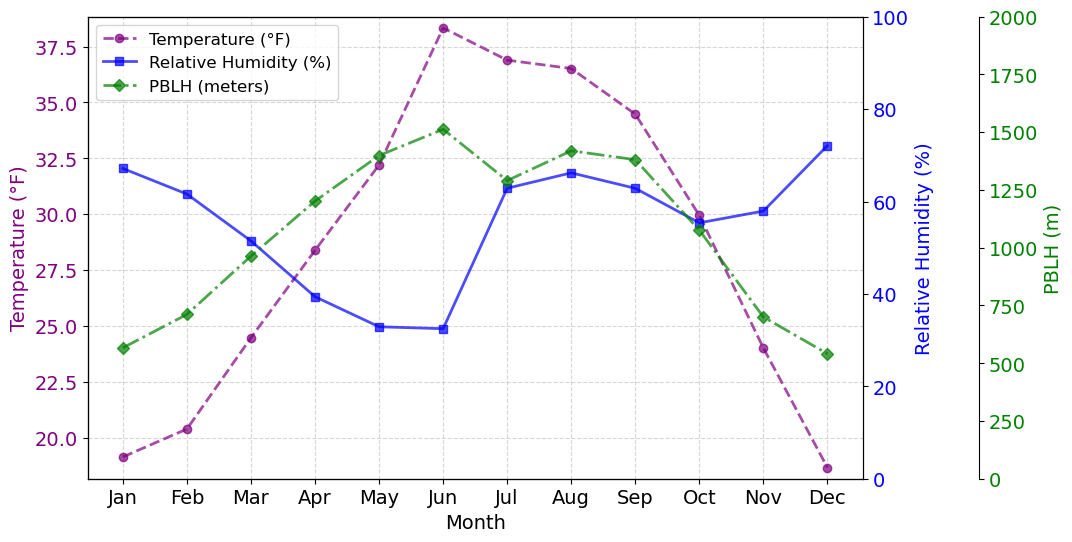

In [15]:
def plot_dual_axis_time_series(tucson_monthly_avgg, tucson_RH_avgg, monthly_averages):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Temperature on the left y-axis
    ax1.plot(tucson_monthly_avgg.index, tucson_monthly_avgg['Sample Measurement'], label='Temperature (°F)', 
             color='purple', marker='o', linestyle='--', linewidth=2, alpha=0.7)
    ax1.set_xlabel('Month', fontsize=14)
    ax1.set_ylabel('Temperature (°F)', color='purple', fontsize=14)
    ax1.tick_params(axis='y', labelcolor='purple', labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)
    ax1.set_xticks(range(12))
    ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

    # Set dynamic y-axis limits for Temperature based on data range
    temp_min, temp_max = tucson_monthly_avgg['Sample Measurement'].min(), tucson_monthly_avgg['Sample Measurement'].max()
    ax1.set_ylim(temp_min - 0.5, temp_max + 0.5)

    # Create the second y-axis for Relative Humidity on the right
    ax2 = ax1.twinx()
    ax2.plot(tucson_RH_avgg.index, tucson_RH_avgg['Sample Measurement'], label='Relative Humidity (%)', 
             color='blue', marker='s', linestyle='-', linewidth=2, alpha=0.7)
    ax2.set_ylabel('Relative Humidity (%)', color='blue', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=14)
    ax2.set_ylim(0, 100)  # Adjust the y-axis limits for relative humidity

    # Create another y-axis for PBLH on the right
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.15))  # Offset the third axis
    ax3.plot(monthly_averages.index, monthly_averages['PBLH'], label='PBLH (meters)', 
             color='green', marker='D', linestyle='-.', linewidth=2, alpha=0.7)
    ax3.set_ylabel('PBLH (m)', color='green', fontsize=14)
    ax3.tick_params(axis='y', labelcolor='green', labelsize=14)
    ax3.set_ylim(0, 2000)  # Adjust the y-axis limits for PBLH

    # Add gridlines for better readability
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Add a title to the plot
    #plt.title('Monthly Average Time Series for Tucson', fontsize=16)

    # Combine legends from all axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left', fontsize=12)

    # Display the plot
    plt.show()

# Example usage:
# Assuming tucson_monthly_avgg, tucson_rh_avg, and monthly_averages contain 'Sample Measurement' and are indexed by month
plot_dual_axis_time_series(tucson_monthly_avgg, tucson_RH_avgg, monthly_averages)


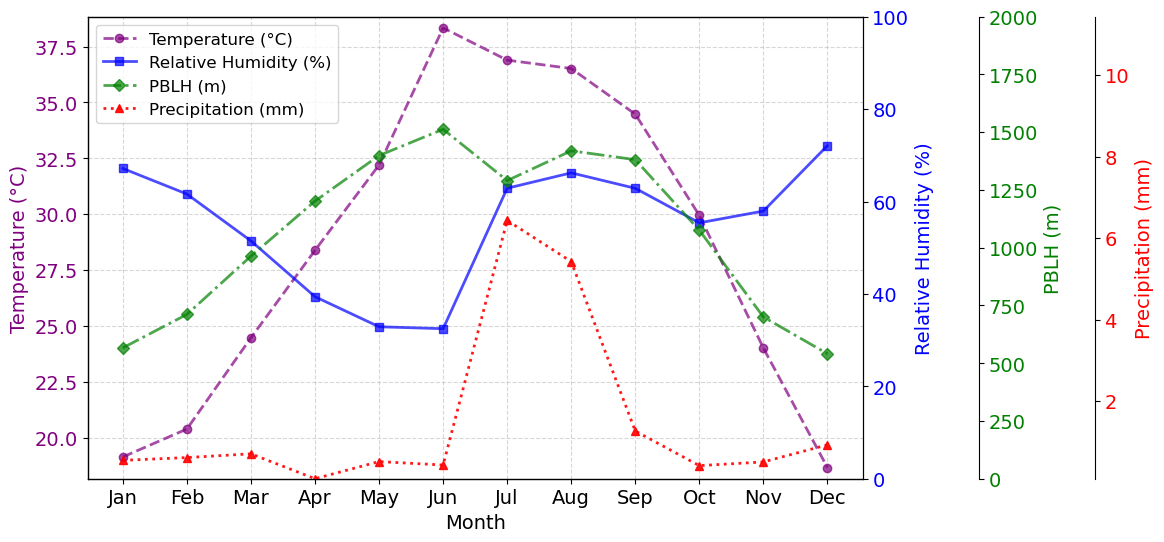

In [16]:
def plot_dual_axis_time_series(tucson_monthly_avgg, tucson_RH_avgg, monthly_averages, monthly_averages_precip):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Temperature on the left y-axis
    ax1.plot(tucson_monthly_avgg.index, tucson_monthly_avgg['Sample Measurement'], label='Temperature (°C)', 
             color='purple', marker='o', linestyle='--', linewidth=2, alpha=0.7)
    ax1.set_xlabel('Month', fontsize=14)
    ax1.set_ylabel('Temperature (°C)', color='purple', fontsize=14)
    ax1.tick_params(axis='y', labelcolor='purple', labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)
    ax1.set_xticks(range(12))
    ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

    # Set dynamic y-axis limits for Temperature based on data range
    temp_min, temp_max = tucson_monthly_avgg['Sample Measurement'].min(), tucson_monthly_avgg['Sample Measurement'].max()
    ax1.set_ylim(temp_min - 0.5, temp_max + 0.5)

    # Create the second y-axis for Relative Humidity on the right
    ax2 = ax1.twinx()
    ax2.plot(tucson_RH_avgg.index, tucson_RH_avgg['Sample Measurement'], label='Relative Humidity (%)', 
             color='blue', marker='s', linestyle='-', linewidth=2, alpha=0.7)
    ax2.set_ylabel('Relative Humidity (%)', color='blue', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=14)
    ax2.set_ylim(0, 100)  # Adjust the y-axis limits for relative humidity

    # Create another y-axis for PBLH
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.15))  # Offset the third axis
    ax3.plot(monthly_averages.index, monthly_averages['PBLH'], label='PBLH (m)', 
             color='green', marker='D', linestyle='-.', linewidth=2, alpha=0.7)
    ax3.set_ylabel('PBLH (m)', color='green', fontsize=14)
    ax3.tick_params(axis='y', labelcolor='green', labelsize=14)
    ax3.set_ylim(0, 2000)  # Adjust the y-axis limits for PBLH

    # Add a fourth axis for Precipitation
    ax4 = ax1.twinx()
    ax4.spines["right"].set_position(("axes", 1.30))  # Offset the fourth axis further
    ax4.plot(monthly_averages_precip.index, monthly_averages_precip['precip'], label='Precipitation (mm)', 
             color='r', marker='^', linestyle=':', linewidth=2, alpha=0.9)
    ax4.set_ylabel('Precipitation (mm)', color='r', fontsize=14)
    ax4.tick_params(axis='y', labelcolor='r', labelsize=14)
    precip_min, precip_max = monthly_averages_precip['precip'].min(), monthly_averages_precip['precip'].max()
    ax4.set_ylim(precip_min, precip_max + 5)  # Adjust the y-axis limits for Precipitation

    # Add gridlines for better readability
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Combine legends from all axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax4.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3 + lines4, labels1 + labels2 + labels3 + labels4, loc='upper left', fontsize=12)

    # Display the plot
    plt.show()

# Example usage:
plot_dual_axis_time_series(tucson_monthly_avgg, tucson_RH_avgg, monthly_averages, monthly_averages_precip)


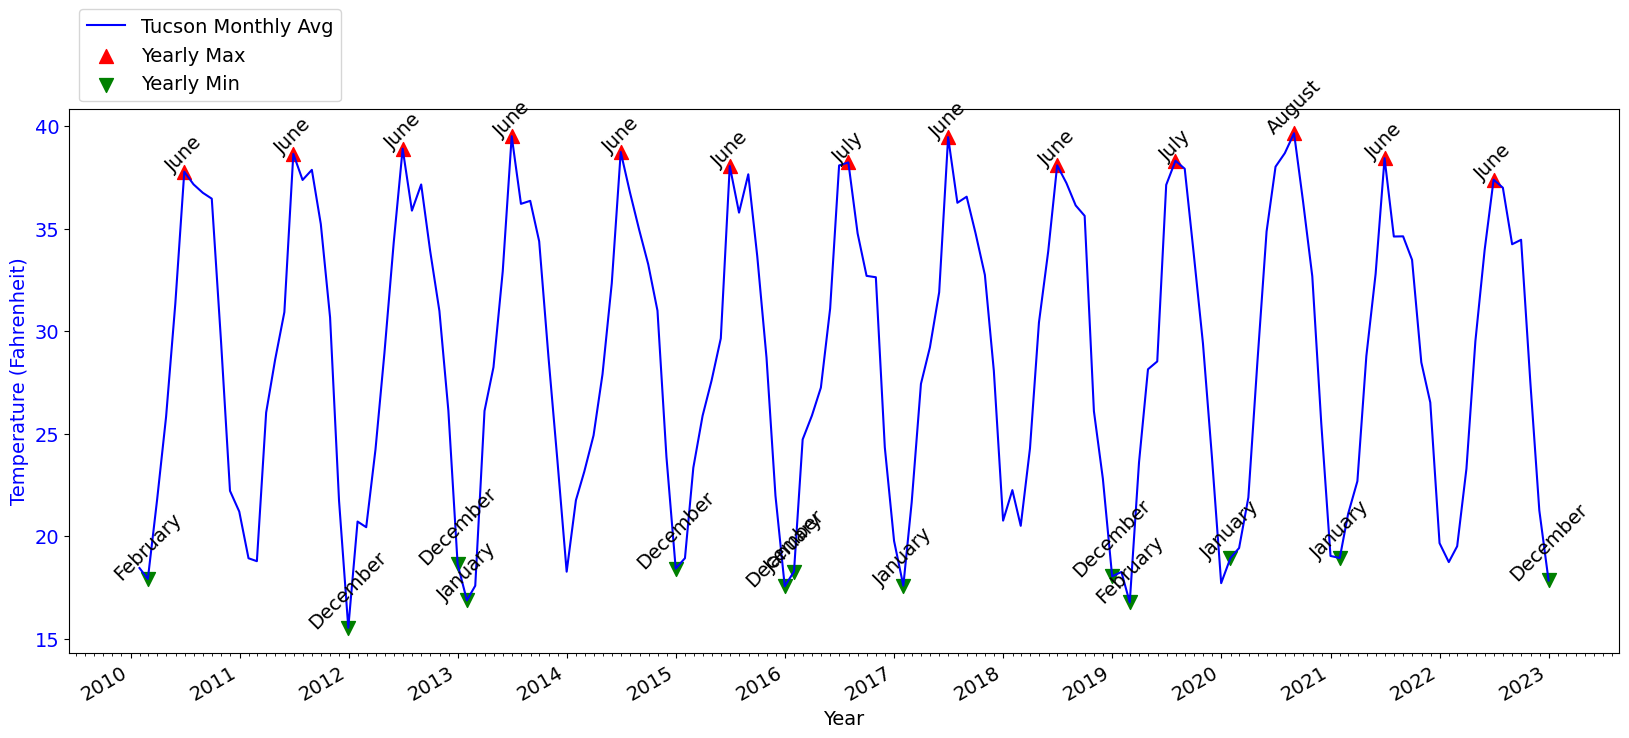

In [17]:
def plot_dual_axis_time_series(tucson_monthly_avg):
    fig, ax1 = plt.subplots(figsize=(20, 8))

    # Plot the main time series for Tucson Monthly Avg
    ax1.plot(tucson_monthly_avg.index, tucson_monthly_avg['Sample Measurement'], label='Tucson Monthly Avg', color='blue')
    ax1.set_xlabel('Year', fontsize=14)
    ax1.set_ylabel('Temperature (Fahrenheit)', color='blue', fontsize=14)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)

    # Formatting x-axis to show years only
    ax1.xaxis.set_major_locator(mdates.YearLocator())  # Place a tick at every year
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the tick labels to show only the year
    ax1.xaxis.set_minor_locator(mdates.MonthLocator())  # Optional: Add minor ticks for months if needed
    fig.autofmt_xdate()  # Automatically formats x-axis labels to fit well

    # Find max and min Sample Measurement for each year
    yearly_max = tucson_monthly_avg.groupby(tucson_monthly_avg.index.year)['Sample Measurement'].idxmax()
    yearly_min = tucson_monthly_avg.groupby(tucson_monthly_avg.index.year)['Sample Measurement'].idxmin()
    
    # Plot markers for max values
    ax1.scatter(yearly_max, tucson_monthly_avg.loc[yearly_max, 'Sample Measurement'], 
                color='red', label='Yearly Max', marker='^', s=100)
    
    # Plot markers for min values
    ax1.scatter(yearly_min, tucson_monthly_avg.loc[yearly_min, 'Sample Measurement'], 
                color='green', label='Yearly Min', marker='v', s=100)
    
    # Add month labels for max and min points, rotated at 45 degrees and colored black
    for idx in yearly_max:
        ax1.text(idx, tucson_monthly_avg.loc[idx, 'Sample Measurement'],
                 tucson_monthly_avg.loc[idx, 'Month'], color='black', fontsize=14, ha='center', rotation=45)
    
    for idx in yearly_min:
        ax1.text(idx, tucson_monthly_avg.loc[idx, 'Sample Measurement'],
                 tucson_monthly_avg.loc[idx, 'Month'], color='black', fontsize=14, ha='center', rotation=45)

    # Add a title to the plot
    #plt.title('Yearly Sample Measurement Time Series for Tucson Monthly Averages', fontsize=14)

    # Adding legends for clarity with increased fontsize
    ax1.legend(loc="upper left", fontsize=14, bbox_to_anchor=(0.0,1.2), bbox_transform=ax1.transAxes)

    # Display the plot
    plt.show()

# Example usage:
# Assuming tucson_monthly_avg contains 'Sample Measurement', 'Month', and a datetime index.
plot_dual_axis_time_series(tucson_monthly_avg)
